## Introduction
Multivariate Curve Resolution (MCR) is a powerful chemometric technique used to decompose complex, mixed-signal data (such as spectroscopic time series!) into pure component spectra and their corresponding concentration profiles. It enables the identification of mixture components without full prior knowledge of the system.

At first glance, MCR seems almost magical. However, it requires reasonable initial estimates to guide the iterative optimization. These initial estimates can be approximations of either the concentration profiles or the pure spectra.

Before applying MCR, it is essential to understand the intrinsic dimensionality of the dataset, that is, how many independent chemical species are contributing to the measured signals.

For this purpose, we begin the analysis with **Singular Value Decomposition (SVD)**.

Unlike MCR, SVD doesn't require any initial estimate or any prior information about the system. It provides a purely mathematical decomposition of the data matrix and allows us to estimate the number of significant components present in the dataset. However, while SVD reveals the dimensionality of the system, it does not directly provide chemically meaningful spectra or concentration profiles.


### Singular Value Decomposition (SVD)
Given the experimental data matrix:

$D \in \mathbb{R}^{n_{time} \times n_{variables}}$

SVD factorizes it as:

$D = U\Sigma V^T$

* The columns of *U* describe independent patterns of variation over time.

* The columns of *V* describe independent spectral patterns.

* The diagonal elements of Σ (the singular values) quantify how important each pattern is.

In other words, SVD decomposes the dataset into a set of orthogonal temporal patterns and orthogonal spectral patterns, ordered from most significant to least significant.

**What do these patterns represent?**

In a time-resolved spectroscopic experiment, we expect that each chemically independent species typically contributes one independent dimension to the dataset. Therefore, the number of significant singular values should correspond to the number of species evolving in time.

By inspecting the magnitude of the singular values (typically via a scree plot), we can estimate how many meaningful components are present before noise dominates.

**Why are SVD components not chemically meaningful?**

Although SVD identifies independent directions of variation in the data, the resulting patterns are mathematical constructs, not physical species. This happens because SVD enforces orthogonality between components, but real chemical spectra are not orthogonal.

As a consequence, the singular vectors in *U* and *V* are typically linear combinations of the true concentration profiles and pure spectra.

Recovering chemically meaningful spectra and concentration profiles requires additional constraints, and this is where MCR-ALS becomes necessary.

## Loading data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# load spectra
dataset = np.load("../data/dataset_1D.npz")

data = dataset["D"]
H_ppm = dataset["ppm"]
time_points = dataset["time_points"]

## Visualization

Text(0.5, 1.0, 'Synthetic demetalation process spectra')

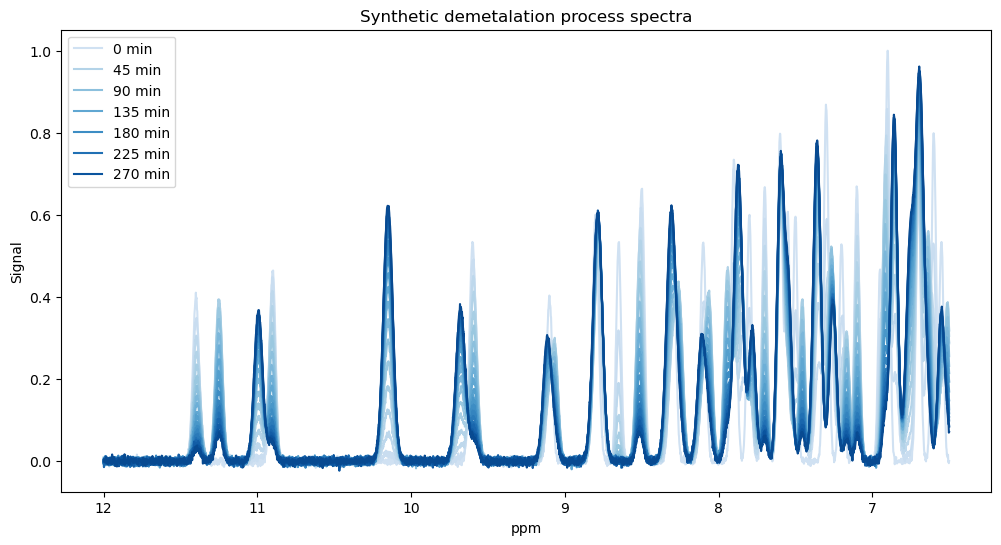

In [3]:
colors= np.linspace(0.2,0.9,len(time_points))
plt.figure(figsize=(12, 6))
for i in range(len(time_points)):
    if i%3==0:
        plt.plot(H_ppm, data[i],label="%.0f min" % time_points[i], color=plt.cm.Blues(colors[i]))
    else:
        plt.plot(H_ppm, data[i], color=plt.cm.Blues(colors[i]))
plt.gca().invert_xaxis()
plt.xlabel("ppm")
plt.ylabel("Signal")
plt.legend(loc="upper left")
plt.title('Synthetic demetalation process spectra')

## SVD

In [5]:
U,s,Vt=np.linalg.svd(data, full_matrices=False)

### Scree plot

Text(0.5, 1.0, 'Singular Values')

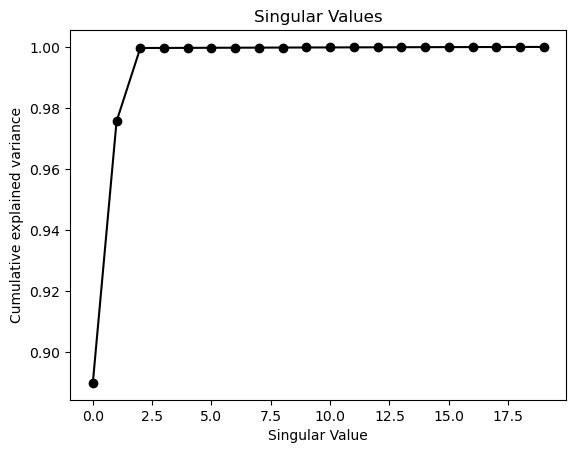

In [7]:
#percentage of variance explained by each singular value
explained_variance = s**2
total_variance = np.sum(explained_variance)
explained_variance_ratio = explained_variance / total_variance
cumulative_explained_variance = np.cumsum(explained_variance_ratio)

plt.plot(cumulative_explained_variance,"ko-")
plt.xlabel("Singular Value")
plt.ylabel("Cumulative explained variance")
plt.title("Singular Values")
#plt.savefig("ScreePlot_SVD.png", bbox_inches='tight', dpi=900)

For this dataset, it is clear that there are 3 main components (3 chemical species). Sometimes this is not that evident, especially if the data is too noisy. You can also analyze the temporal patterns associated with each singular value. Those singular values related to chemical species will present a time-dependent concentration, while noise is usually present as random variability.

### Concentrations profiles

Text(0.5, 0.98, 'SVD concentration profiles')

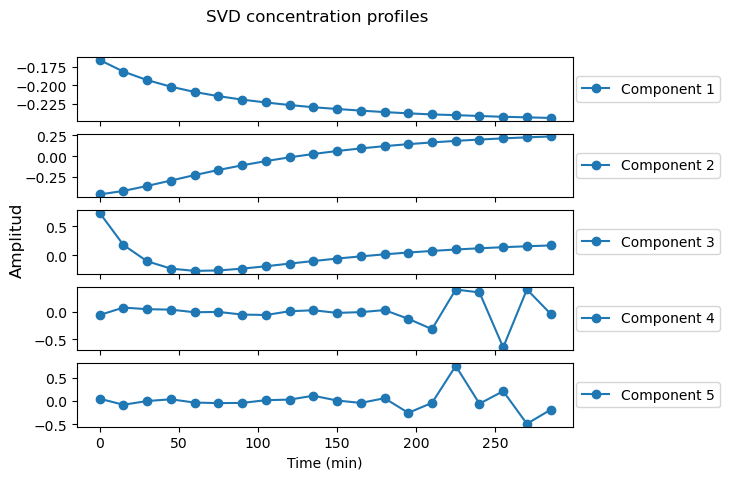

In [10]:
nComp = 5
fig, axes = plt.subplots(nComp, 1, sharex=True)

for i in range(nComp):
    axes[i].plot(time_points, U[:, i], "o-",
                 label=f"Component {i+1}")
    axes[i].legend(loc='center right', bbox_to_anchor=(1.31, 0.5))

axes[-1].set_xlabel("Time (min)")
fig.supylabel("Amplitud")
fig.suptitle("SVD concentration profiles")

We can see again that only the first 3 singular values present a time-dependent concentration. So it is safe to assume that there are at most 3 chemical species involved.

Unlike the apo and holo spectra, which either appear or disappear over time, the intermediate presents a maximum of concentration at a middle time point. Any singular value related to the intermediate should present either a maximum or a minimum at a middle time point. In this case, that component is the third one. This component presents a minimum between the 5th and 6th time point, so we will use the spectrum at the 5th time point as the estimate for the intermediate.

### Singular values' patterns

Text(0.5, 0.98, 'SVD  patterns')

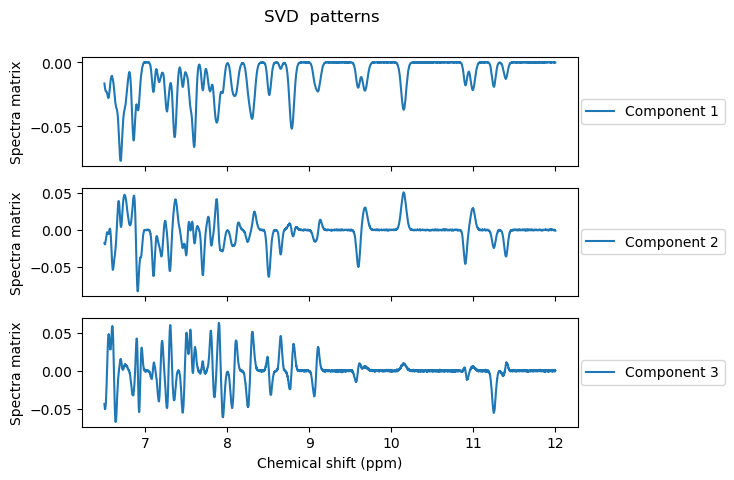

In [13]:
fig,axes=plt.subplots(3,1, sharex=True)
for i in range(3):
    axes[i].plot(H_ppm,Vt[i,:],label=f"Component {i+1}")
    axes[i].legend(loc='center right', bbox_to_anchor=(1.31, 0.5))
    axes[i].set_ylabel("Spectra matrix")
axes[i].set_xlabel("Chemical shift (ppm)")

fig.suptitle("SVD  patterns")

As you can see in theplot above, the patterns obtained do not look like NMR spectra, and usually have negative values.

## Number of components we are gonna use for the MCR: 3
## Estimate for the intermediate spectrum: spectrum at the 5th time point 